In [12]:
from __future__ import annotations

from dataclasses import dataclass, field
from pathlib import Path
from typing import Literal, Sequence
import random
import subprocess

import mido
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pretty_midi
import IPython.display as ipd


PitchClass = int
PitchClassRow = list[PitchClass]
RowFormType = Literal["P", "I", "R", "RI"]


# -------------------------
# Pitch material
# -------------------------

def validate_pitch_class(pc: int, modulus: int = 12) -> None:
    if not isinstance(pc, (int, np.integer)):
        raise TypeError("Pitch class must be an integer.")
    pc = int(pc)
    if pc < 0 or pc >= modulus:
        raise ValueError(f"Pitch class must be in range 0 to {modulus - 1}.")


def validate_row(row: Sequence[int], modulus: int = 12) -> None:
    if len(row) != modulus:
        raise ValueError(f"Row must contain exactly {modulus} pitch classes.")
    for pc in row:
        validate_pitch_class(pc, modulus=modulus)
    if set(row) != set(range(modulus)):
        raise ValueError(f"Row must contain each pitch class from 0 to {modulus - 1} exactly once.")


def generate_row(modulus: int = 12, seed: int | None = None) -> PitchClassRow:
    rng = random.Random(seed)
    row = list(range(modulus))
    rng.shuffle(row)
    return row


def transpose_row(row: Sequence[int], interval: int, modulus: int = 12) -> PitchClassRow:
    return [(int(pc) + interval) % modulus for pc in row]


def normalise_row(row: Sequence[int], modulus: int = 12) -> PitchClassRow:
    validate_row(row, modulus=modulus)
    return transpose_row(row, -int(row[0]), modulus=modulus)


def invert_row(row: Sequence[int], axis: int = 0, modulus: int = 12) -> PitchClassRow:
    validate_pitch_class(axis, modulus=modulus)
    return [(2 * axis - int(pc)) % modulus for pc in row]


def retrograde_row(row: Sequence[int]) -> PitchClassRow:
    return list(reversed([int(pc) for pc in row]))


def rotate_row(row: Sequence[int], steps: int) -> PitchClassRow:
    row = [int(pc) for pc in row]
    steps = steps % len(row)
    return row[steps:] + row[:steps]


@dataclass(frozen=True)
class RowForm:
    form_type: RowFormType
    transposition: int
    row: PitchClassRow

    @property
    def label(self) -> str:
        return f"{self.form_type}{self.transposition}"


@dataclass
class TwelveToneMaterial:
    raw_row: PitchClassRow
    normalise: bool = True
    modulus: int = 12

    def __post_init__(self) -> None:
        validate_row(self.raw_row, modulus=self.modulus)
        self.raw_row = [int(pc) for pc in self.raw_row]
        self.p0_row = normalise_row(self.raw_row, self.modulus) if self.normalise else list(self.raw_row)
        self.matrix = self._build_matrix()

    def _build_matrix(self) -> np.ndarray:
        first_col = invert_row(self.p0_row, axis=self.p0_row[0], modulus=self.modulus)
        matrix = np.zeros((self.modulus, self.modulus), dtype=int)

        for i, start_pc in enumerate(first_col):
            interval = start_pc - self.p0_row[0]
            matrix[i, :] = transpose_row(self.p0_row, interval, self.modulus)

        return matrix

    def prime(self, transposition: int = 0) -> RowForm:
        n = transposition % self.modulus
        return RowForm("P", n, list(self.matrix[n, :]))

    def inversion(self, transposition: int = 0) -> RowForm:
        n = transposition % self.modulus
        return RowForm("I", n, list(self.matrix[:, n]))

    def retrograde(self, transposition: int = 0) -> RowForm:
        p = self.prime(transposition)
        return RowForm("R", p.transposition, retrograde_row(p.row))

    def retrograde_inversion(self, transposition: int = 0) -> RowForm:
        i = self.inversion(transposition)
        return RowForm("RI", i.transposition, retrograde_row(i.row))

    def get_form(self, form_type: RowFormType, transposition: int = 0) -> RowForm:
        if form_type == "P":
            return self.prime(transposition)
        if form_type == "I":
            return self.inversion(transposition)
        if form_type == "R":
            return self.retrograde(transposition)
        if form_type == "RI":
            return self.retrograde_inversion(transposition)
        raise ValueError(f"Unknown row form: {form_type}")

    def all_forms(self) -> dict[str, RowForm]:
        forms = {}
        for n in range(self.modulus):
            for form_type in ["P", "I", "R", "RI"]:
                form = self.get_form(form_type, n)
                forms[form.label] = form
        return forms

In [13]:
VelocityMode = Literal["fixed", "normal", "uniform"]
DurationMode = Literal["fixed", "normal", "uniform", "exponential"]


# -------------------------
# Arrangement model
# -------------------------

@dataclass
class MutationConfig:
    transpose_probability: float = 0.35
    transpose_intervals: tuple[int, ...] = (-6, -5, -3, -2, 1, 2, 3, 5, 6)
    invert_probability: float = 0.15
    retrograde_probability: float = 0.20
    rotate_probability: float = 0.20
    rotate_steps: tuple[int, ...] = (1, 2, 3, 4, 5, 6)

    note_rate_mutation_probability: float = 0.35
    note_rate_multiplier_range: tuple[float, float] = (0.70, 1.40)

    duration_mutation_probability: float = 0.35
    duration_multiplier_range: tuple[float, float] = (0.70, 1.40)

    velocity_mutation_probability: float = 0.35
    velocity_shift_range: tuple[int, int] = (-14, 14)
    velocity_sd_range: tuple[float, float] = (0.00, 0.25)


@dataclass
class BirthDeathConfig:
    song_length: float = 90.0
    initial_population: int = 2
    min_population: int = 1
    max_population: int = 10

    birth_rate: float = 0.08
    death_rate: float = 0.06

    note_rate_mean: float = 2.5
    note_rate_sd: float = 0.35

    duration_mean: float = 0.25
    duration_sd: float = 0.25
    duration_mode: DurationMode = "normal"
    duration_min: float = 0.05
    duration_max: float = 2.00

    velocity_mean: int = 72
    velocity_sd: float = 0.10
    velocity_mode: VelocityMode = "normal"

    seed: int | None = None


@dataclass
class ToneRowVoice:
    voice_id: int
    row: PitchClassRow
    birth_time: float
    note_rate: float

    duration_mean: float = 0.25
    duration_sd: float = 0.25
    duration_mode: DurationMode = "normal"
    duration_min: float = 0.05
    duration_max: float = 2.00

    velocity_mean: int = 72
    velocity_sd: float = 0.10
    velocity_mode: VelocityMode = "normal"

    current_index: int = 0
    death_time: float | None = None
    parent_id: int | None = None
    mutation_history: list[str] = field(default_factory=list)

    @property
    def is_alive(self) -> bool:
        return self.death_time is None

    def next_pitch_class(self) -> tuple[int, int, int]:
        row_index = self.current_index % len(self.row)
        row_cycle = self.current_index // len(self.row)
        pc = int(self.row[row_index])
        self.current_index += 1
        return pc, row_index, row_cycle


@dataclass
class PitchClassEvent:
    time: float
    duration: float
    voice_id: int
    pitch_class: int
    velocity: int
    row_index: int
    row_cycle: int
    parent_id: int | None = None


@dataclass
class PopulationEvent:
    time: float
    event_type: str
    voice_id: int
    population_size: int
    parent_id: int | None = None
    mutation_history: str = ""


@dataclass
class BirthDeathToneRowProcess:
    rows: list[PitchClassRow]
    config: BirthDeathConfig
    mutation_config: MutationConfig

    voices: dict[int, ToneRowVoice] = field(default_factory=dict)
    pitch_events: list[PitchClassEvent] = field(default_factory=list)
    population_events: list[PopulationEvent] = field(default_factory=list)

    def __post_init__(self) -> None:
        self.rng = random.Random(self.config.seed)
        self.np_rng = np.random.default_rng(self.config.seed)
        self.next_voice_id = 0

        if not self.rows:
            raise ValueError("At least one tone row must be provided.")
        for row in self.rows:
            validate_row(row)

    def alive_voices(self) -> list[ToneRowVoice]:
        return [v for v in self.voices.values() if v.is_alive]

    def population_size(self) -> int:
        return len(self.alive_voices())

    def sample_note_rate(self) -> float:
        rate = self.rng.normalvariate(
            self.config.note_rate_mean,
            self.config.note_rate_mean * self.config.note_rate_sd,
        )
        return max(rate, 0.01)

    def sample_duration(self, voice: ToneRowVoice) -> float:
        if voice.duration_mode == "fixed":
            duration = voice.duration_mean
        elif voice.duration_mode == "uniform":
            duration = self.rng.uniform(voice.duration_min, voice.duration_max)
        elif voice.duration_mode == "exponential":
            duration = self.np_rng.exponential(voice.duration_mean)
        else:
            duration = self.rng.normalvariate(
                voice.duration_mean,
                voice.duration_mean * voice.duration_sd,
            )
        return float(max(voice.duration_min, min(voice.duration_max, duration)))

    def sample_velocity(self, voice: ToneRowVoice) -> int:
        if voice.velocity_mode == "fixed":
            velocity = voice.velocity_mean
        elif voice.velocity_mode == "uniform":
            lo = max(0, int(voice.velocity_mean * (1 - voice.velocity_sd)))
            hi = min(127, int(voice.velocity_mean * (1 + voice.velocity_sd)))
            velocity = self.rng.randint(lo, hi)
        else:
            velocity = self.rng.normalvariate(
                voice.velocity_mean,
                voice.velocity_mean * voice.velocity_sd,
            )
        return int(max(0, min(127, round(velocity))))

    def create_initial_voice(self, time: float) -> ToneRowVoice:
        row = list(self.rng.choice(self.rows))
        voice = ToneRowVoice(
            voice_id=self.next_voice_id,
            row=row,
            birth_time=time,
            note_rate=self.sample_note_rate(),
            duration_mean=self.config.duration_mean,
            duration_sd=self.config.duration_sd,
            duration_mode=self.config.duration_mode,
            duration_min=self.config.duration_min,
            duration_max=self.config.duration_max,
            velocity_mean=self.config.velocity_mean,
            velocity_sd=self.config.velocity_sd,
            velocity_mode=self.config.velocity_mode,
            mutation_history=["initial"],
        )
        self.voices[voice.voice_id] = voice
        self.next_voice_id += 1
        return voice

    def choose_parent(self) -> ToneRowVoice:
        alive = self.alive_voices()
        if not alive:
            raise ValueError("Cannot choose parent when no voices are alive.")
        return self.rng.choice(alive)

    def mutate_row(self, row: PitchClassRow) -> tuple[PitchClassRow, list[str]]:
        mc = self.mutation_config
        mutated = list(row)
        history = []

        if self.rng.random() < mc.transpose_probability:
            interval = self.rng.choice(mc.transpose_intervals)
            mutated = transpose_row(mutated, interval)
            history.append(f"T{interval:+d}")

        if self.rng.random() < mc.invert_probability:
            mutated = invert_row(mutated, axis=mutated[0])
            history.append("I")

        if self.rng.random() < mc.retrograde_probability:
            mutated = retrograde_row(mutated)
            history.append("R")

        if self.rng.random() < mc.rotate_probability:
            steps = self.rng.choice(mc.rotate_steps)
            mutated = rotate_row(mutated, steps)
            history.append(f"ROT{steps}")

        validate_row(mutated)
        return mutated, history or ["copy"]

    def mutate_note_rate(self, parent_rate: float) -> float:
        mc = self.mutation_config
        if self.rng.random() >= mc.note_rate_mutation_probability:
            return parent_rate
        lo, hi = mc.note_rate_multiplier_range
        return max(0.01, parent_rate * self.rng.uniform(lo, hi))

    def mutate_duration_profile(self, parent: ToneRowVoice) -> tuple[float, list[str]]:
        mc = self.mutation_config
        if self.rng.random() >= mc.duration_mutation_probability:
            return parent.duration_mean, []
        lo, hi = mc.duration_multiplier_range
        multiplier = self.rng.uniform(lo, hi)
        return max(parent.duration_min, min(parent.duration_max, parent.duration_mean * multiplier)), [f"DURx{multiplier:.2f}"]

    def mutate_velocity_profile(self, parent: ToneRowVoice) -> tuple[int, float, list[str]]:
        mc = self.mutation_config
        if self.rng.random() >= mc.velocity_mutation_probability:
            return parent.velocity_mean, parent.velocity_sd, []

        shift = self.rng.randint(*mc.velocity_shift_range)
        velocity_mean = int(max(0, min(127, parent.velocity_mean + shift)))
        velocity_sd = self.rng.uniform(*mc.velocity_sd_range)
        return velocity_mean, velocity_sd, [f"VEL{shift:+d}"]

    def create_child_voice(self, time: float) -> ToneRowVoice:
        parent = self.choose_parent()

        child_row, row_history = self.mutate_row(parent.row)
        child_note_rate = self.mutate_note_rate(parent.note_rate)
        child_duration_mean, duration_history = self.mutate_duration_profile(parent)
        velocity_mean, velocity_sd, velocity_history = self.mutate_velocity_profile(parent)

        mutation_history = row_history + duration_history + velocity_history

        voice = ToneRowVoice(
            voice_id=self.next_voice_id,
            row=child_row,
            birth_time=time,
            note_rate=child_note_rate,
            duration_mean=child_duration_mean,
            duration_sd=parent.duration_sd,
            duration_mode=parent.duration_mode,
            duration_min=parent.duration_min,
            duration_max=parent.duration_max,
            velocity_mean=velocity_mean,
            velocity_sd=velocity_sd,
            velocity_mode=parent.velocity_mode,
            parent_id=parent.voice_id,
            mutation_history=mutation_history,
        )
        self.voices[voice.voice_id] = voice
        self.next_voice_id += 1
        return voice

    def kill_voice(self, time: float) -> ToneRowVoice | None:
        alive = self.alive_voices()
        if not alive:
            return None
        voice = self.rng.choice(alive)
        voice.death_time = time
        return voice

    def generate_initial_population(self) -> None:
        for _ in range(self.config.initial_population):
            voice = self.create_initial_voice(time=0.0)
            self.population_events.append(
                PopulationEvent(
                    time=0.0,
                    event_type="birth",
                    voice_id=voice.voice_id,
                    population_size=self.population_size(),
                    mutation_history="initial",
                )
            )

    def generate_voice_notes_until(self, voice: ToneRowVoice, start_time: float, end_time: float) -> None:
        t = start_time

        while t < end_time and voice.is_alive:
            t += self.np_rng.exponential(1 / voice.note_rate)

            if t >= end_time:
                break

            pc, row_index, row_cycle = voice.next_pitch_class()

            self.pitch_events.append(
                PitchClassEvent(
                    time=t,
                    duration=self.sample_duration(voice),
                    voice_id=voice.voice_id,
                    pitch_class=pc,
                    velocity=self.sample_velocity(voice),
                    row_index=row_index,
                    row_cycle=row_cycle,
                    parent_id=voice.parent_id,
                )
            )

    def next_population_wait(self) -> float:
        n = self.population_size()
        total_rate = self.config.birth_rate if n == 0 else (self.config.birth_rate * n) + (self.config.death_rate * n)
        return self.np_rng.exponential(1 / max(total_rate, 1e-9))

    def choose_birth_or_death(self) -> str:
        n = self.population_size()

        if n <= self.config.min_population:
            return "birth"
        if n >= self.config.max_population:
            return "death"

        birth_intensity = self.config.birth_rate * n
        death_intensity = self.config.death_rate * n
        birth_probability = birth_intensity / (birth_intensity + death_intensity)

        return "birth" if self.rng.random() < birth_probability else "death"

    def run(self) -> tuple[list[PitchClassEvent], list[PopulationEvent]]:
        self.generate_initial_population()
        current_time = 0.0

        while current_time < self.config.song_length:
            next_time = min(current_time + self.next_population_wait(), self.config.song_length)

            for voice in self.alive_voices():
                self.generate_voice_notes_until(voice, current_time, next_time)

            current_time = next_time

            if current_time >= self.config.song_length:
                break

            event_type = self.choose_birth_or_death()

            if event_type == "birth":
                voice = self.create_initial_voice(current_time) if self.population_size() == 0 else self.create_child_voice(current_time)
            else:
                voice = self.kill_voice(current_time)

            if voice is not None:
                self.population_events.append(
                    PopulationEvent(
                        time=current_time,
                        event_type=event_type,
                        voice_id=voice.voice_id,
                        population_size=self.population_size(),
                        parent_id=voice.parent_id,
                        mutation_history=", ".join(voice.mutation_history),
                    )
                )

        return self.pitch_events, self.population_events

In [16]:
# -------------------------
# MIDI rendering
# -------------------------

def seconds_to_ticks(time_seconds: float, bpm: float = 120, ticks_per_beat: int = 480) -> int:
    return int(round((time_seconds * bpm / 60) * ticks_per_beat))


def pitch_class_to_midi_note(
    pitch_class: int,
    base_octave: int = 4,
    octave_span: int = 3,
    voice_id: int = 0,
) -> int:
    octave = base_octave + (voice_id % octave_span)
    return int(max(0, min(127, int(pitch_class) + 12 * octave)))


def pitch_events_to_midi(
    pitch_events: list[PitchClassEvent],
    output_path: str | Path,
    bpm: int = 120,
    ticks_per_beat: int = 480,
    base_octave: int = 4,
    octave_span: int = 3,
) -> Path:
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    midi = mido.MidiFile(ticks_per_beat=ticks_per_beat)
    track = mido.MidiTrack()
    midi.tracks.append(track)

    track.append(mido.MetaMessage("set_tempo", tempo=mido.bpm2tempo(bpm), time=0))
    track.append(mido.MetaMessage("track_name", name="birth_death_12tone", time=0))

    midi_events = []

    for event in sorted(pitch_events, key=lambda e: e.time):
        note = pitch_class_to_midi_note(
            pitch_class=event.pitch_class,
            base_octave=base_octave,
            octave_span=octave_span,
            voice_id=event.voice_id,
        )

        start_tick = seconds_to_ticks(event.time, bpm, ticks_per_beat)
        end_tick = start_tick + seconds_to_ticks(event.duration, bpm, ticks_per_beat)

        midi_events.append((start_tick, mido.Message("note_on", note=note, velocity=event.velocity, time=0)))
        midi_events.append((end_tick, mido.Message("note_off", note=note, velocity=0, time=0)))

    midi_events.sort(key=lambda x: x[0])

    previous_tick = 0
    for absolute_tick, message in midi_events:
        message.time = max(0, absolute_tick - previous_tick)
        track.append(message)
        previous_tick = absolute_tick

    midi.save(output_path)
    return output_path


def play_midi_in_notebook(midi_path: str | Path, sample_rate: int = 44100, normalize: bool = True):
    midi_data = pretty_midi.PrettyMIDI(str(midi_path))
    audio = midi_data.synthesize(fs=sample_rate)

    if normalize:
        peak = np.max(np.abs(audio))
        if peak > 0:
            audio = audio / peak

    return ipd.Audio(audio, rate=sample_rate)


def open_in_reaper(midi_path: str | Path) -> None:
    midi_path = Path(midi_path)

    possible_paths = [
        r"C:\Program Files\REAPER (x64)\reaper.exe",
        r"C:\Program Files\REAPER\reaper.exe",
    ]

    for path in possible_paths:
        if Path(path).exists():
            subprocess.Popen([path, str(midi_path)])
            print(f"Opened in REAPER: {midi_path}")
            return

    print(f"REAPER not found automatically. MIDI saved here: {midi_path}")

Generated stochastic 12-tone birth-death MIDI
MIDI path: ..\generated\midi\birth_death_12tone_test.mid

12-tone material
Raw row: [7, 5, 2, 8, 9, 6, 11, 3, 4, 0, 1, 10]
P0 row:  [0, 10, 7, 1, 2, 11, 4, 8, 9, 5, 6, 3]

Population stats
Initial population: 2
Final population:   4
Min population:     1
Max population:     6
Mean population:    3.56
Total births:       19
Total deaths:       15
Total voices:       19

Note stats
Total notes:        193
Voices used:        16
Notes per second:   3.22

Pitch-class counts
{0: 15, 1: 16, 2: 16, 3: 13, 4: 17, 5: 16, 6: 18, 7: 16, 8: 20, 9: 16, 10: 15, 11: 15}

Duration stats
count    193.000
mean       0.215
std        0.063
min        0.066
25%        0.179
50%        0.212
75%        0.253
max        0.495

Velocity stats
count    193.00
mean      75.71
std       17.77
min       35.00
25%       63.00
50%       77.00
75%       88.00
max      126.00

First 10 voices


,voice_id,parent_id,birth_time,death_time,note_rate,duration_mean,velocity_mean,velocity_sd,mutation_history
0,0,NaN,0.000000,43.182689,0.990602,0.250000,72,0.180000,[initial]
1,1,NaN,0.000000,2.016799,1.005230,0.250000,72,0.180000,[initial]
2,2,0.0,3.061616,6.066233,0.990602,0.250000,72,0.180000,[T+6]
3,3,0.0,9.981609,20.152862,0.990602,0.250000,72,0.180000,[R]
4,4,3.0,14.440070,14.525999,1.112910,0.234443,64,0.278812,"[T+6, I, R, ROT1, DURx0.94, VEL-8]"
5,5,3.0,15.831074,22.232923,0.990602,0.250000,72,0.180000,[T+5]
6,6,5.0,16.708482,32.077122,0.980573,0.250000,72,0.085528,"[copy, VEL+0]"
7,7,3.0,19.201824,31.248048,0.990602,0.197876,72,0.180000,"[T+5, DURx0.79]"
8,8,7.0,25.376582,29.558652,0.990602,0.141876,74,0.264067,"[I, DURx0.72, VEL+2]"
9,9,6.0,26.779133,36.707255,0.980573,0.250000,62,0.136214,"[ROT1, VEL-10]"


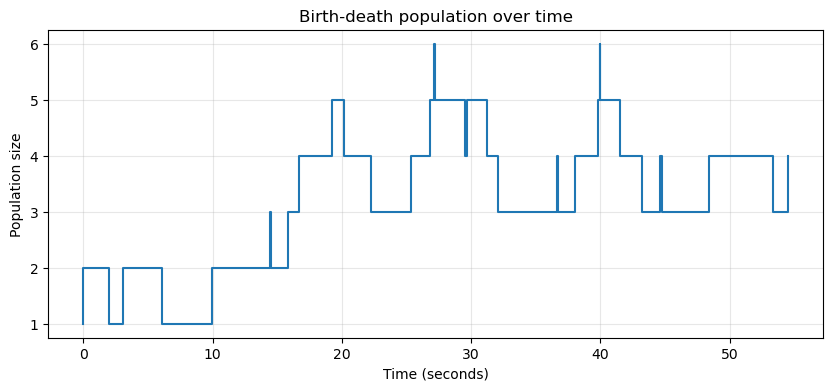

In [18]:
# -------------------------
# Parameters
# -------------------------

song_name = "birth_death_12tone_test"
midi_path = Path("../generated/midi") / f"{song_name}.mid"

row_seed = 42
process_seed = 123

raw_row = generate_row(modulus=12, seed=row_seed)
material = TwelveToneMaterial(raw_row=raw_row, normalise=True)

input_rows = [
    material.get_form("P", 0).row,
    material.get_form("I", 0).row,
    material.get_form("R", 0).row,
    material.get_form("RI", 0).row,
]

bd_config = BirthDeathConfig(
    song_length=60.0,
    initial_population=2,
    min_population=1,
    max_population=12,
    birth_rate=0.08,
    death_rate=0.068,
    note_rate_mean=2.5,
    note_rate_sd=0.35,
    duration_mean=0.25,
    duration_sd=0.25,
    duration_mode="normal",
    duration_min=0.05,
    duration_max=2.00,
    velocity_mean=72,
    velocity_sd=0.18,
    velocity_mode="normal",
    seed=process_seed,
)

mutation_config = MutationConfig(
    transpose_probability=0.5,
    transpose_intervals=(-6, -5, -3, -2, 1, 2, 3, 5, 6),
    invert_probability=0.20,
    retrograde_probability=0.25,
    rotate_probability=0.25,
    rotate_steps=(1, 2, 3, 4, 5, 6),
    note_rate_mutation_probability=0.40,
    note_rate_multiplier_range=(0.70, 1.45),
    duration_mutation_probability=0.40,
    duration_multiplier_range=(0.70, 1.45),
    velocity_mutation_probability=0.40,
    velocity_shift_range=(-16, 16),
    velocity_sd_range=(0.00, 0.30),
)

bpm = 100
ticks_per_beat = 480
base_octave = 4
octave_span = 4


# -------------------------
# Run
# -------------------------

process = BirthDeathToneRowProcess(
    rows=input_rows,
    config=bd_config,
    mutation_config=mutation_config,
)

pitch_events, population_events = process.run()

saved_path = pitch_events_to_midi(
    pitch_events=pitch_events,
    output_path=midi_path,
    bpm=bpm,
    ticks_per_beat=ticks_per_beat,
    base_octave=base_octave,
    octave_span=octave_span,
)


# -------------------------
# Stats
# -------------------------

pitch_df = pd.DataFrame([event.__dict__ for event in pitch_events])
pop_df = pd.DataFrame([event.__dict__ for event in population_events])
voice_df = pd.DataFrame([voice.__dict__ for voice in process.voices.values()])

print("Generated stochastic 12-tone birth-death MIDI")
print(f"MIDI path: {saved_path}")
print()
print("12-tone material")
print(f"Raw row: {material.raw_row}")
print(f"P0 row:  {material.p0_row}")
print()
print("Population stats")
print(f"Initial population: {bd_config.initial_population}")
print(f"Final population:   {pop_df['population_size'].iloc[-1] if not pop_df.empty else 0}")
print(f"Min population:     {pop_df['population_size'].min() if not pop_df.empty else 0}")
print(f"Max population:     {pop_df['population_size'].max() if not pop_df.empty else 0}")
print(f"Mean population:    {pop_df['population_size'].mean() if not pop_df.empty else 0:.2f}")
print(f"Total births:       {(pop_df['event_type'] == 'birth').sum() if not pop_df.empty else 0}")
print(f"Total deaths:       {(pop_df['event_type'] == 'death').sum() if not pop_df.empty else 0}")
print(f"Total voices:       {process.next_voice_id}")
print()
print("Note stats")
print(f"Total notes:        {len(pitch_events)}")
print(f"Voices used:        {pitch_df['voice_id'].nunique() if not pitch_df.empty else 0}")
print(f"Notes per second:   {len(pitch_events) / bd_config.song_length:.2f}")

if not pitch_df.empty:
    print()
    print("Pitch-class counts")
    print(pitch_df["pitch_class"].value_counts().sort_index().to_dict())

    print()
    print("Duration stats")
    print(pitch_df["duration"].describe().round(3).to_string())

    print()
    print("Velocity stats")
    print(pitch_df["velocity"].describe().round(2).to_string())

if not voice_df.empty:
    print()
    print("First 10 voices")
    display(
        voice_df[
            [
                "voice_id",
                "parent_id",
                "birth_time",
                "death_time",
                "note_rate",
                "duration_mean",
                "velocity_mean",
                "velocity_sd",
                "mutation_history",
            ]
        ].head(10)
    )


# -------------------------
# Plots
# -------------------------

if not pop_df.empty:
    plt.figure(figsize=(10, 4))
    plt.step(pop_df["time"], pop_df["population_size"], where="post")
    plt.title("Birth-death population over time")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Population size")
    plt.grid(True, alpha=0.3)
    plt.show()

# if not pitch_df.empty:
#     plt.figure(figsize=(10, 4))
#     pitch_df.groupby("voice_id").size().plot(kind="bar")
#     plt.title("Notes generated by voice")
#     plt.xlabel("Voice ID")
#     plt.ylabel("Note count")
#     plt.grid(True, axis="y", alpha=0.3)
#     plt.show()

#     plt.figure(figsize=(10, 4))
#     pitch_df["duration"].plot(kind="hist", bins=20)
#     plt.title("Duration distribution")
#     plt.xlabel("Duration seconds")
#     plt.ylabel("Count")
#     plt.grid(True, alpha=0.3)
#     plt.show()

#     plt.figure(figsize=(10, 4))
#     pitch_df["velocity"].plot(kind="hist", bins=20)
#     plt.title("Velocity distribution")
#     plt.xlabel("Velocity")
#     plt.ylabel("Count")
#     plt.grid(True, alpha=0.3)
#     plt.show()


# -------------------------
# Audio preview
# -------------------------

play_midi_in_notebook(saved_path)